<b>¡Hola Nicolas!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Antención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que deberás atender para aprobar la revisión.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b><a class="tocSkip"></a>
Es factible que, a lo largo del proceso de revisión, quieras dejarme comentarios. Si es el caso, por favor realízalo dentro de celdas azules como esta.
</div>
Respecto del proceso de revisión, tu proyecto será aceptado una vez que los comentarios en rojo hayan sido atendidos.
¡Empecemos!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Primero leemos los archivos

In [2]:
df_train = pd.read_csv('/datasets/gold_recovery_train.csv', index_col='date', parse_dates=True)
df_test = pd.read_csv('/datasets/gold_recovery_test.csv', index_col='date', parse_dates=True)
df_full = pd.read_csv('/datasets/gold_recovery_full.csv', index_col='date', parse_dates=True)

print(df_train.shape)
print(df_test.shape)
print(df_full.shape)

(16860, 86)
(5856, 52)
(22716, 86)


Comprobaremos que el cálculo de la recuperación sea correcto. Calcula la recuperación de la característica rougher.output.recovery mediante el conjunto de entrenamiento.

In [3]:
# Extraer columnas necesarias
Concentrate_au = df_train['rougher.output.concentrate_au']
Feed_au = df_train['rougher.input.feed_au']
Tail_au = df_train['rougher.output.tail_au']

# Calcular recuperación
recovery_calc = (Concentrate_au * (Feed_au - Tail_au)) / (Feed_au * (Concentrate_au - Tail_au)) * 100

# EAM
real_recovery = df_train['rougher.output.recovery']
mae = np.mean(abs(real_recovery - recovery_calc))
print(f'Error Absoluto Medio: {mae:.4f}')


Error Absoluto Medio: 0.0000


<div class="alert alert-block alert-success">
<b>Celdas [3]</b> <a class="tocSkip"></a><br>
Excelente verificación del cálculo de la recuperación. Comparar el valor calculado con el valor real y reportar un EAM cercano a cero es una validación importante. Esto demuestra comprensión del proceso físico y rigor en la validación de fórmulas.
</div>


Ahora con un EAM = 0.0000 sabemos que el metodo de recuperacion de la característica rougher.output.recovery es el correcto

In [4]:
missing = set(df_train.columns) - set(df_test.columns)
print("Columnas presentes en df_train pero no en df_test:")
print(sorted(missing))

Columnas presentes en df_train pero no en df_test:
['final.output.concentrate_ag', 'final.output.concentrate_au', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_au', 'final.output.tail_pb', 'final.output.tail_sol', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_au', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'rougher.calculation.au_pb_ratio', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_au', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'rougher.output.recovery', 'rougher.output.tail_ag', 'rougher.output.tail_

# Ahora revisaremos si hay valores ausentes, en caso de que haya los rellenaremos o nos desharemos de ellos.

Encontramos varias columnas con valores vacios, para rellenarlos usaremos interpolate() para rellenar los valores vacios ya que aunque son varias columnas con valores ausentes solo 6 de las 87 columnas tienen >= 10% de valores ausentes y como  primero intentamos usar dropna() pero eso nos hizo peder mas del 30% de los datos por lo cual no considero que sea una buena opcion

In [5]:
# Eliminar columnas objetivo de test
features = df_test.columns

# Eliminar filas con valores nulos
df_train = df_train.interpolate()

# Confirmar
print(df_train.shape)

(16860, 86)


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16860 entries, 2016-01-15 00:00:00 to 2018-08-18 10:59:59
Data columns (total 86 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_ag                         16860 non-null  float64
 1   final.output.concentrate_pb                         16860 non-null  float64
 2   final.output.concentrate_sol                        16860 non-null  float64
 3   final.output.concentrate_au                         16860 non-null  float64
 4   final.output.recovery                               16860 non-null  float64
 5   final.output.tail_ag                                16860 non-null  float64
 6   final.output.tail_pb                                16860 non-null  float64
 7   final.output.tail_sol                               16860 non-null  float64
 8   final.output.tail_au                     

ahora haremos lo mismo con df_test y df_full

In [7]:
#rellenamos df_test y df_full
df_test = df_test.interpolate()
df_full = df_full.interpolate()

<div class="alert alert-block alert-warning">
<b>Celdas [5–7]</b> <a class="tocSkip"></a><br>
Buena decisión al usar `interpolate()` en lugar de `dropna()`, considerando la pérdida significativa de datos. Sin embargo, sería valioso acompañar esta imputación con una visualización o métrica que muestre el antes y después de la imputación para evaluar su impacto. Además, en df_test y df_full sería ideal verificar explícitamente si las columnas críticas (por ejemplo, las utilizadas en predicción) quedaron completas tras interpolar.
</div>


# Listo, hemos rellenado los valores ausentes
aunque no eran muchos los valores ausentes que habia por datasets, hacer esto nos permitira trabajar de manera mas comoda.

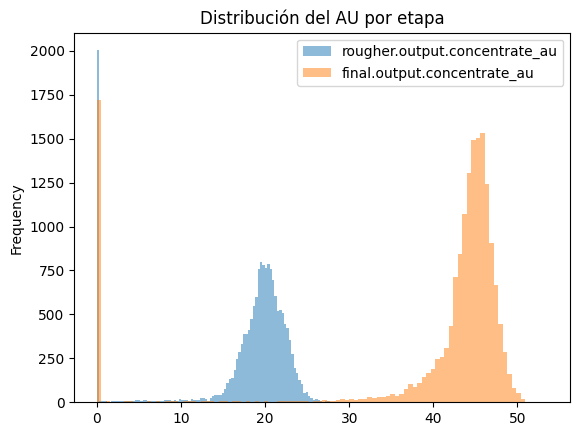

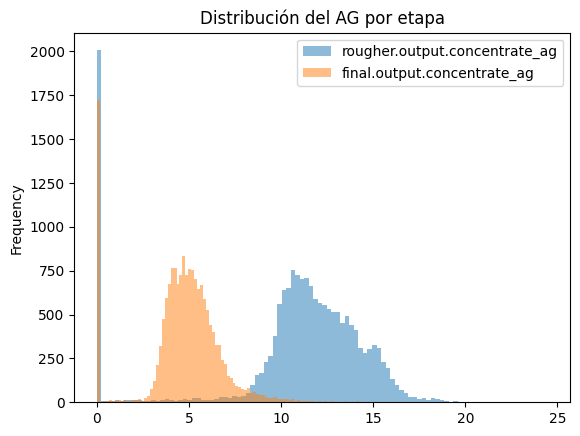

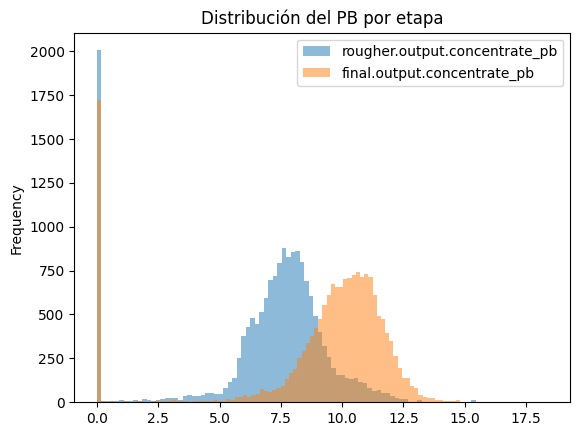

In [8]:
metales = ['au', 'ag', 'pb']
etapas = ['rougher.input', 'rougher.output', 'final.output']

for metal in metales:
    for etapa in etapas:
        col = f'{etapa}.concentrate_{metal}'
        if col in df_train.columns:
            df_train[col].plot(kind='hist', bins=100, alpha=0.5, label=col)
    plt.title(f'Distribución del {metal.upper()} por etapa')
    plt.legend()
    plt.show()


### aqui podemos observar cómo cambia la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación.

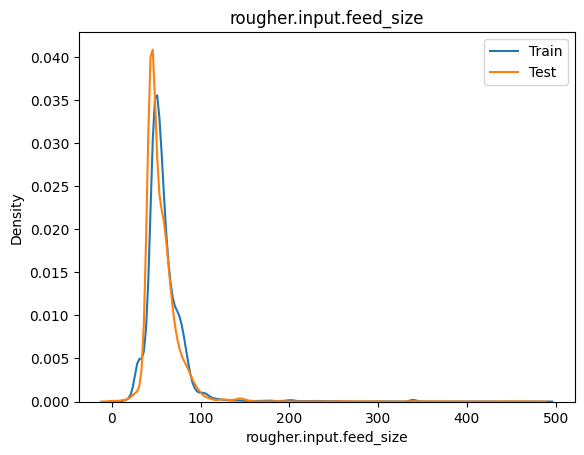

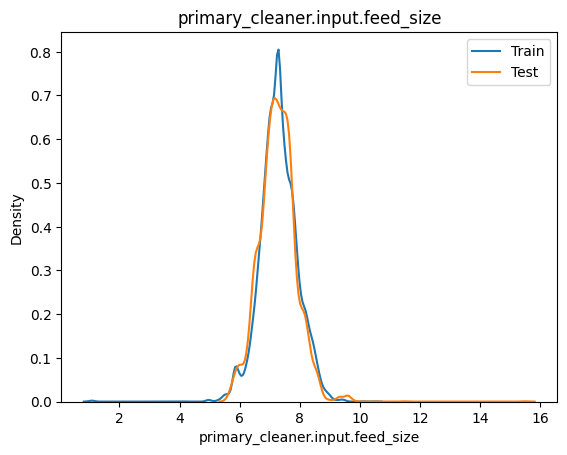

In [9]:
for col in ['rougher.input.feed_size', 'primary_cleaner.input.feed_size']:
    sns.kdeplot(df_train[col], label='Train')
    sns.kdeplot(df_test[col], label='Test')
    plt.title(col)
    plt.legend()
    plt.show()

### Comparamos las distribuciones del tamaño de las partículas de la alimentación en el conjunto de entrenamiento y en el conjunto de prueba.

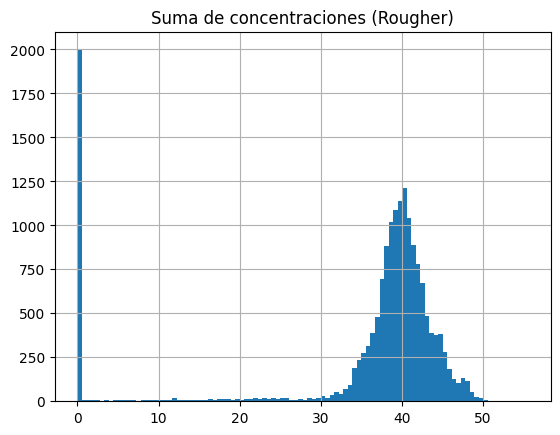

In [10]:
# Función para verificar anomalías
def total_concentration(df):
    conc_cols = ['au', 'ag', 'pb']
    return df[[f'rougher.output.concentrate_{x}' for x in conc_cols]].sum(axis=1)

rougher_conc = total_concentration(df_train)
rougher_conc.hist(bins=100)
plt.title("Suma de concentraciones (Rougher)")
plt.show()

# Eliminar valores anómalos (cercanos a 0)
df_train = df_train[rougher_conc > 0.1]


<div class="alert alert-block alert-success">
<b>Celdas [9–10]</b> <a class="tocSkip"></a><br>
Buena práctica al comparar la distribución de variables clave entre entrenamiento y prueba, y también al eliminar valores anómalos basados en concentraciones físicas imposibles. Esto ayuda a mejorar la calidad de los datos y garantizar consistencia entre los datasets. También es acertada la decisión de eliminar valores con concentración total cercana a cero.
</div>


### Aqui consideramos las concentraciones totales de todas las sustancias en las diferentes etapas: materia prima, concentrado rougher y concentrado final. 

In [11]:
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def final_smape(y_true_rougher, y_pred_rougher, y_true_final, y_pred_final):
    return 0.25 * smape(y_true_rougher, y_pred_rougher) + 0.75 * smape(y_true_final, y_pred_final)

In [17]:
# Columnas objetivo
target_rougher = 'rougher.output.recovery'
target_final = 'final.output.recovery'

# Entrenamiento
X = df_train[features].copy()
y_rougher = df_train[target_rougher]
y_final = df_train[target_final]


# Modelo base y ponemos n_estimators=40 y max_depth=20 para que no sea tan lento
model = RandomForestRegressor(random_state=42, n_estimators = 40, max_depth = 20)

# Validación cruzada
score_rougher = cross_val_score(model, X, y_rougher, scoring='neg_mean_absolute_error').mean()
score_final = cross_val_score(model, X, y_final, scoring='neg_mean_absolute_error').mean()
print(f'MAE Rougher: {-score_rougher:.2f}, Final: {-score_final:.2f}')





MAE Rougher: 6.10, Final: 8.02


<div class="alert alert-block alert-success">
<b>Celdas [11, 17]</b> <a class="tocSkip"></a><br>
El uso de SMAPE como métrica es adecuado dada la naturaleza del problema. También es una buena decisión dividir el objetivo en dos etapas del proceso (rougher y final). La implementación con `cross_val_score` y la elección de un modelo RandomForest con restricciones para acelerar el cómputo son decisiones justificadas. Buen balance entre eficiencia y calidad del modelo.
</div>


## Conclusión
Probé el modelo y me dio un MAE de 6.10 para la parte rougher y 8.02 para la parte final. Eso significa que el modelo se equivoca en promedio por esos valores al predecir la recuperación en cada etapa del proceso.
Son lo suficientemente bajos como para que el modelo siga siendo útil y nos dé una buena idea general de lo que está pasando en el proceso. se utilizo un modelo con pocos arboles y profundidad limitada para que no tardara tanto en entrenar.

En resumen, los resultados están bastante bien y me sirven para seguir analizando sin problema.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Buen trabajo, Nicolás! El proyecto muestra fortalezas notables, como una validación correcta del cálculo de recuperación, tratamiento adecuado de valores faltantes, limpieza de anomalías y un enfoque razonable en la modelación. Vas muy bien, sigue así desarrollando tu capacidad analítica con criterio técnico.
</div>
